# MCDI504 · Machine Learning I
## Semana 03 · Evaluación Sumativa 2 · Fases 2 y 3
### `F3_RedesNeuronales.ipynb`

**Grupo 6:** Luis Díaz Giral, Gonzalo Bouldres y Eduardo Contreras  
**Programa:** Magíster en Ciencia de Datos e Inteligencia Artificial · Universidad Andrés Bello

Este cuaderno integra la evidencia computacional de regresión y clasificación requerida para la evaluación. La ejecución genera tablas y figuras en `Semana3/outputs/` y `Semana3/figures/`. La interpretación de resultados y las conclusiones se desarrollan posteriormente a partir de la corrida guardada.


## 0. Preparación del entorno y reproducibilidad

Se fija `random_state=42`, se localiza la raíz del repositorio y se eliminan únicamente los artefactos generados por corridas anteriores dentro de `Semana3/outputs/` y `Semana3/figures/`. Los datos fuente y las evidencias históricas de Semanas 1 y 2 se conservan.


In [1]:
from pathlib import Path
import json
import platform
import time
import warnings
import hashlib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def localizar_raiz_repo(inicio: Path) -> Path:
    inicio = inicio.resolve()
    for candidato in [inicio, *inicio.parents]:
        if (candidato / 'Semana2').is_dir() and (candidato / 'Semana3').is_dir():
            return candidato
    raise FileNotFoundError(
        'No fue posible localizar la raíz del repositorio. '
        'Ejecute el notebook desde la raíz, Semana3 o Semana3/notebook.'
    )

ROOT = localizar_raiz_repo(Path.cwd())
S3 = ROOT / 'Semana3'
DATA_DIR = S3 / 'data'
OUT_DIR = S3 / 'outputs'
FIG_DIR = S3 / 'figures'
for d in (OUT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

for d in (OUT_DIR, FIG_DIR):
    for p in d.iterdir():
        if p.is_file() and p.name not in {'.gitkeep', 'README.md'}:
            p.unlink()

versiones = pd.DataFrame({
    'Componente': ['Python', 'NumPy', 'pandas', 'scikit-learn', 'Matplotlib'],
    'Version': [
        platform.python_version(), np.__version__, pd.__version__,
        sklearn.__version__, matplotlib.__version__
    ],
})
versiones.to_csv(OUT_DIR / '00_versiones_entorno.csv', index=False)
display(versiones)
print('Repositorio localizado correctamente:', ROOT.name)


,Componente,Version
0,Python,3.12.4
1,NumPy,1.26.4
2,pandas,2.2.2
3,scikit-learn,1.4.2
4,Matplotlib,3.8.4


Repositorio localizado correctamente: mcdi504-machine-learning-1


# 1. Fase 2 · Regresión supervisada
## 1.1 Conjunto de datos y preparación analítica

Se utiliza California Housing con `MedHouseVal` como variable objetivo continua. Se registran la estructura del conjunto de datos, los predictores disponibles, el control de valores faltantes y los estadísticos descriptivos.


In [2]:
REG_DATA = DATA_DIR / 'california_housing.csv'
reg_df = pd.read_csv(REG_DATA)
TARGET_REG = 'MedHouseVal'
FEATURES_REG = [c for c in reg_df.columns if c != TARGET_REG]

perfil_reg = pd.DataFrame({
    'Elemento': ['Filas', 'Columnas_totales', 'Predictores', 'Variable_objetivo', 'Duplicados'],
    'Valor': [len(reg_df), reg_df.shape[1], len(FEATURES_REG), TARGET_REG, int(reg_df.duplicated().sum())],
})
control_nulos_reg = (
    reg_df.isna().sum().rename('Valores_faltantes').reset_index().rename(columns={'index':'Variable'})
)
estadisticos_reg = reg_df.describe().T.reset_index().rename(columns={'index':'Variable'})

perfil_reg.to_csv(OUT_DIR / '01_reg_perfil_dataset.csv', index=False)
control_nulos_reg.to_csv(OUT_DIR / '02_reg_control_nulos.csv', index=False)
estadisticos_reg.to_csv(OUT_DIR / '03_reg_estadisticos_descriptivos.csv', index=False)

display(perfil_reg)
display(control_nulos_reg)
display(estadisticos_reg)


,Elemento,Valor
0,Filas,20640
1,Columnas_totales,9
2,Predictores,8
3,Variable_objetivo,MedHouseVal
4,Duplicados,0


,Variable,Valores_faltantes
0,MedInc,0
1,HouseAge,0
2,AveRooms,0
3,AveBedrms,0
4,Population,0
5,AveOccup,0
6,Latitude,0
7,Longitude,0
8,MedHouseVal,0


,Variable,count,mean,std,min,25%,50%,75%,max
0,MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
1,HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
2,AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
3,AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
4,Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
5,AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
6,Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
7,Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
8,MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## 1.2 Partición, selección de variable y transformación

Se reserva 20% de las observaciones para prueba con `random_state=42`. La selección del predictor de la regresión lineal simple se basa en la correlación de Pearson calculada únicamente con el conjunto de entrenamiento. `StandardScaler` se ajusta con entrenamiento y luego se aplica a prueba.


In [3]:
X_reg = reg_df[FEATURES_REG].copy()
y_reg = reg_df[TARGET_REG].copy()

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

split_reg = pd.DataFrame({
    'Objeto': ['X_train', 'X_test', 'y_train', 'y_test'],
    'Filas': [len(X_train_reg), len(X_test_reg), len(y_train_reg), len(y_test_reg)],
    'Porcentaje_aprox': [80, 20, 80, 20],
})
split_reg.to_csv(OUT_DIR / '04_reg_dimensiones_split.csv', index=False)

corr_train = (
    X_train_reg.assign(**{TARGET_REG: y_train_reg})
    .corr(numeric_only=True)[TARGET_REG]
    .drop(TARGET_REG)
)
corr_table = (
    corr_train.sort_values(key=lambda s: s.abs(), ascending=False)
    .rename('Correlacion_Pearson_train')
    .reset_index().rename(columns={'index':'Variable'})
)
SIMPLE_FEATURE = corr_table.loc[0, 'Variable']
corr_table.to_csv(OUT_DIR / '05_reg_correlaciones_entrenamiento.csv', index=False)

scaler_reg = StandardScaler()
X_train_reg_scaled = pd.DataFrame(
    scaler_reg.fit_transform(X_train_reg), columns=FEATURES_REG, index=X_train_reg.index
)
X_test_reg_scaled = pd.DataFrame(
    scaler_reg.transform(X_test_reg), columns=FEATURES_REG, index=X_test_reg.index
)
scaler_reg_table = pd.DataFrame({
    'Variable': FEATURES_REG,
    'Media_aprendida_train': scaler_reg.mean_,
    'Escala_aprendida_train': scaler_reg.scale_,
})
scaler_reg_table.to_csv(OUT_DIR / '06_reg_parametros_standard_scaler.csv', index=False)

display(split_reg)
display(corr_table)
print('Predictor seleccionado para la regresión lineal simple:', SIMPLE_FEATURE)


,Objeto,Filas,Porcentaje_aprox
0,X_train,16512,80
1,X_test,4128,20
2,y_train,16512,80
3,y_test,4128,20


,Variable,Correlacion_Pearson_train
0,MedInc,0.690647
1,AveRooms,0.158485
2,Latitude,-0.142983
3,HouseAge,0.103706
4,AveBedrms,-0.051351
5,Longitude,-0.046349
6,Population,-0.026032
7,AveOccup,-0.022030


Predictor seleccionado para la regresión lineal simple: MedInc


## 1.3 Evidencia exploratoria de regresión

Se generan la distribución de la variable objetivo y el perfil de correlaciones del conjunto de entrenamiento para documentar la preparación y la selección de variables.


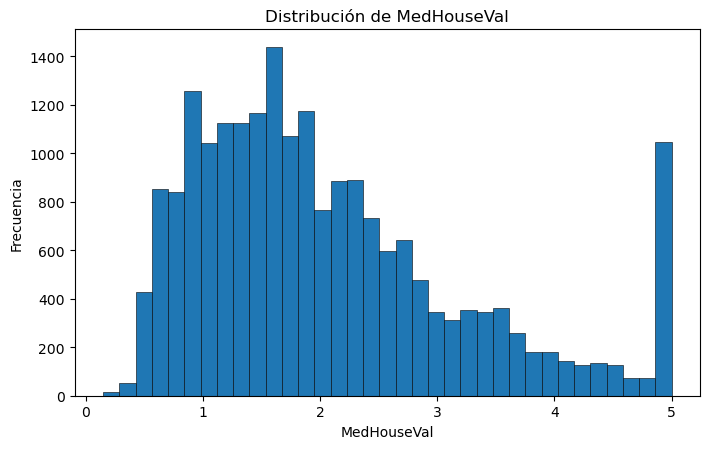

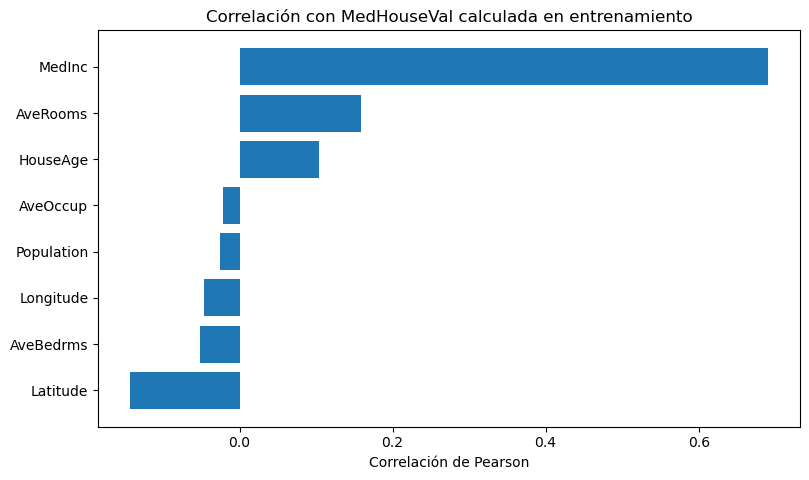

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.hist(y_reg, bins=35, edgecolor='black', linewidth=0.4)
ax.set(title='Distribución de MedHouseVal', xlabel='MedHouseVal', ylabel='Frecuencia')
fig.tight_layout()
fig.savefig(FIG_DIR / '01_reg_distribucion_medhouseval.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8.2, 4.9))
plot_corr = corr_table.sort_values('Correlacion_Pearson_train')
ax.barh(plot_corr['Variable'], plot_corr['Correlacion_Pearson_train'])
ax.set(title='Correlación con MedHouseVal calculada en entrenamiento', xlabel='Correlación de Pearson')
fig.tight_layout()
fig.savefig(FIG_DIR / '02_reg_correlaciones_entrenamiento.png', dpi=180, bbox_inches='tight')
plt.show()


## 1.4 Implementación inicial de modelos de regresión

Se implementan regresión lineal simple, regresión lineal multivariable, árbol de decisión y MLP de regresión. El árbol se utiliza posteriormente para el ajuste de hiperparámetros, ya que su complejidad puede controlarse mediante parámetros explícitos de estructura.


In [5]:
reg_models = {}
reg_pred_train = {}
reg_pred_test = {}
reg_fichas = []

lin_simple = LinearRegression()
lin_simple.fit(X_train_reg_scaled[[SIMPLE_FEATURE]], y_train_reg)
reg_models['Regresión lineal simple'] = lin_simple
reg_pred_train['Regresión lineal simple'] = lin_simple.predict(X_train_reg_scaled[[SIMPLE_FEATURE]])
reg_pred_test['Regresión lineal simple'] = lin_simple.predict(X_test_reg_scaled[[SIMPLE_FEATURE]])
reg_fichas.append({
    'Modelo':'Regresión lineal simple',
    'Configuracion':f'predictor={SIMPLE_FEATURE}; StandardScaler ajustado con entrenamiento'
})

lin_multi = LinearRegression()
lin_multi.fit(X_train_reg_scaled, y_train_reg)
reg_models['Regresión lineal multivariable'] = lin_multi
reg_pred_train['Regresión lineal multivariable'] = lin_multi.predict(X_train_reg_scaled)
reg_pred_test['Regresión lineal multivariable'] = lin_multi.predict(X_test_reg_scaled)
reg_fichas.append({
    'Modelo':'Regresión lineal multivariable',
    'Configuracion':'8 predictores; StandardScaler ajustado con entrenamiento'
})

arbol_inicial = DecisionTreeRegressor(
    criterion='squared_error', splitter='best', max_depth=5,
    min_samples_split=2, min_samples_leaf=1, random_state=RANDOM_STATE,
)
arbol_inicial.fit(X_train_reg, y_train_reg)
reg_models['Árbol inicial'] = arbol_inicial
reg_pred_train['Árbol inicial'] = arbol_inicial.predict(X_train_reg)
reg_pred_test['Árbol inicial'] = arbol_inicial.predict(X_test_reg)
reg_fichas.append({
    'Modelo':'Árbol inicial',
    'Configuracion':'criterion=squared_error; max_depth=5; min_samples_split=2; min_samples_leaf=1; random_state=42'
})

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(100,), activation='relu', solver='adam',
    alpha=0.0001, learning_rate_init=0.001, max_iter=500,
    early_stopping=True, validation_fraction=0.10,
    n_iter_no_change=10, random_state=RANDOM_STATE,
)
mlp_reg.fit(X_train_reg_scaled, y_train_reg)
reg_models['MLP regresión'] = mlp_reg
reg_pred_train['MLP regresión'] = mlp_reg.predict(X_train_reg_scaled)
reg_pred_test['MLP regresión'] = mlp_reg.predict(X_test_reg_scaled)
reg_fichas.append({
    'Modelo':'MLP regresión',
    'Configuracion':'hidden_layer_sizes=(100,); activation=relu; solver=adam; alpha=0.0001; learning_rate_init=0.001; early_stopping=True; max_iter=500; random_state=42'
})

reg_fichas_df = pd.DataFrame(reg_fichas)
reg_fichas_df.to_csv(OUT_DIR / '07_reg_fichas_configuracion_inicial.csv', index=False)
display(reg_fichas_df)


,Modelo,Configuracion
0,Regresión lineal simple,predictor=MedInc; StandardScaler ajustado con ...
1,Regresión lineal multivariable,8 predictores; StandardScaler ajustado con ent...
2,Árbol inicial,criterion=squared_error; max_depth=5; min_samp...
3,MLP regresión,"hidden_layer_sizes=(100,); activation=relu; so..."


## 1.5 Ajuste de hiperparámetros

El ajuste del árbol se realiza exclusivamente sobre el conjunto de entrenamiento mediante validación cruzada de 5 particiones. Se evalúan `max_depth`, `min_samples_split` y `min_samples_leaf` utilizando RMSE de validación como criterio de selección. El conjunto de prueba permanece reservado hasta finalizar el ajuste.


Configuraciones evaluadas: 72
Mejores hiperparámetros seleccionados por CV: {'max_depth': 12, 'min_samples_leaf': 10, 'min_samples_split': 2}


,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score,RMSE_train_CV,RMSE_validacion_CV
0,12,2,10,-0.466116,-0.618781,0.017761,1,0.466116,0.618781
1,12,5,10,-0.466116,-0.618781,0.017761,1,0.466116,0.618781
2,12,10,10,-0.466116,-0.618781,0.017761,1,0.466116,0.618781
3,None,2,10,-0.442482,-0.619904,0.019649,4,0.442482,0.619904
4,None,5,10,-0.442482,-0.619904,0.019649,4,0.442482,0.619904
5,None,10,10,-0.442482,-0.619904,0.019649,4,0.442482,0.619904
6,9,2,10,-0.538862,-0.633009,0.013093,7,0.538862,0.633009
7,9,5,10,-0.538862,-0.633009,0.013093,7,0.538862,0.633009
8,9,10,10,-0.538862,-0.633009,0.013093,7,0.538862,0.633009
9,12,2,5,-0.417407,-0.636683,0.016427,10,0.417407,0.636683


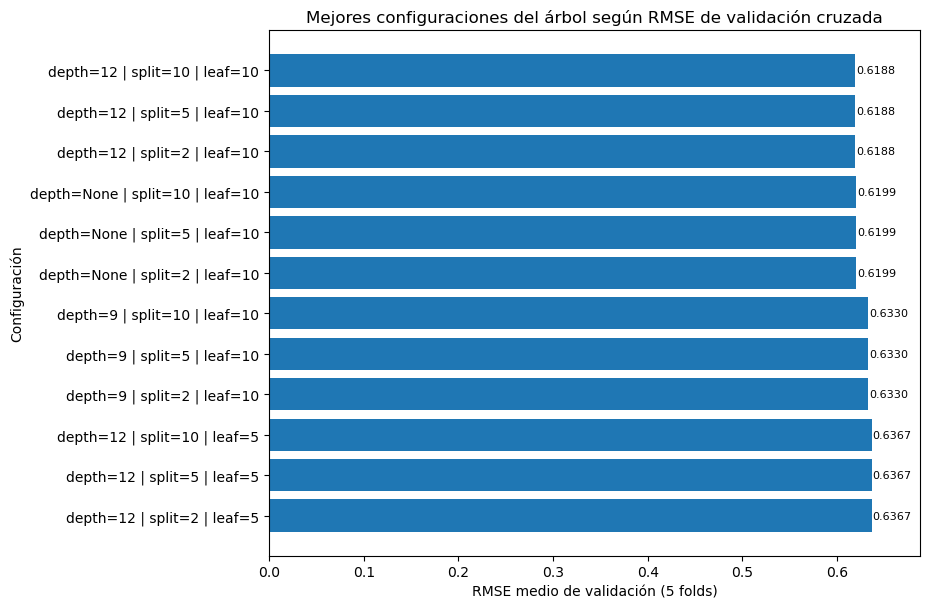

In [6]:
param_grid_reg = {
    'max_depth': [3, 5, 7, 9, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],
}
cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_reg = GridSearchCV(
    estimator=DecisionTreeRegressor(criterion='squared_error', random_state=RANDOM_STATE),
    param_grid=param_grid_reg,
    scoring='neg_root_mean_squared_error',
    cv=cv_reg,
    n_jobs=-1,
    return_train_score=True,
)
search_reg.fit(X_train_reg, y_train_reg)

cv_reg_full = pd.DataFrame(search_reg.cv_results_)
cv_reg_export = cv_reg_full[[
    'param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf',
    'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].copy()
cv_reg_export['RMSE_train_CV'] = -cv_reg_export['mean_train_score']
cv_reg_export['RMSE_validacion_CV'] = -cv_reg_export['mean_test_score']
cv_reg_export = cv_reg_export.sort_values(['rank_test_score', 'RMSE_validacion_CV']).reset_index(drop=True)
cv_reg_export.to_csv(OUT_DIR / '08_reg_ajuste_hiperparametros_cv.csv', index=False)

best_params_reg = {
    k: (int(v) if isinstance(v, (np.integer, int)) else v)
    for k, v in search_reg.best_params_.items()
}
with open(OUT_DIR / '09_reg_mejores_hiperparametros.json', 'w', encoding='utf-8') as f:
    json.dump(best_params_reg, f, ensure_ascii=False, indent=2)

arbol_ajustado = search_reg.best_estimator_
reg_models['Árbol ajustado'] = arbol_ajustado
reg_pred_train['Árbol ajustado'] = arbol_ajustado.predict(X_train_reg)
reg_pred_test['Árbol ajustado'] = arbol_ajustado.predict(X_test_reg)

print('Configuraciones evaluadas:', len(cv_reg_export))
print('Mejores hiperparámetros seleccionados por CV:', best_params_reg)
display(cv_reg_export.head(15))

plot_cv = cv_reg_export.head(12).copy()
labels = [
    f"depth={('None' if pd.isna(d) else int(d))} | split={int(s)} | leaf={int(l)}"
    for d, s, l in zip(
        plot_cv['param_max_depth'],
        plot_cv['param_min_samples_split'],
        plot_cv['param_min_samples_leaf']
    )
]
plot_cv = plot_cv.assign(Etiqueta=labels).sort_values('RMSE_validacion_CV', ascending=False)

fig, ax = plt.subplots(figsize=(9.4, 6.2))
ax.barh(plot_cv['Etiqueta'], plot_cv['RMSE_validacion_CV'])
for y_pos, value in enumerate(plot_cv['RMSE_validacion_CV']):
    ax.text(value + 0.001, y_pos, f'{value:.4f}', va='center', fontsize=8)
ax.set(
    title='Mejores configuraciones del árbol según RMSE de validación cruzada',
    xlabel='RMSE medio de validación (5 folds)',
    ylabel='Configuración'
)
ax.set_xlim(0, plot_cv['RMSE_validacion_CV'].max() * 1.08)
fig.tight_layout()
fig.savefig(FIG_DIR / '03_reg_ajuste_hiperparametros_cv.png', dpi=180, bbox_inches='tight')
plt.show()


## 1.6 Evaluación y comparación de regresión

Para cada modelo se calculan MSE, RMSE y R² en entrenamiento y prueba. También se registran brechas train–test para disponer de evidencia complementaria de generalización.


,Modelo,MSE_train,RMSE_train,R2_train,MSE_test,RMSE_test,R2_test,Gap_R2_train_test,Gap_RMSE_test_train
0,Regresión lineal simple,0.699145,0.836149,0.476993,0.709116,0.842090,0.458859,0.018134,0.005941
1,Regresión lineal multivariable,0.517933,0.719676,0.612551,0.555892,0.745581,0.575788,0.036763,0.025906
2,Árbol inicial,0.484343,0.695948,0.637679,0.524515,0.724234,0.599732,0.037947,0.028286
3,MLP regresión,0.280958,0.530054,0.789825,0.301732,0.549301,0.769742,0.020083,0.019247
4,Árbol ajustado,0.216618,0.465422,0.837955,0.363096,0.602575,0.722914,0.115042,0.137153


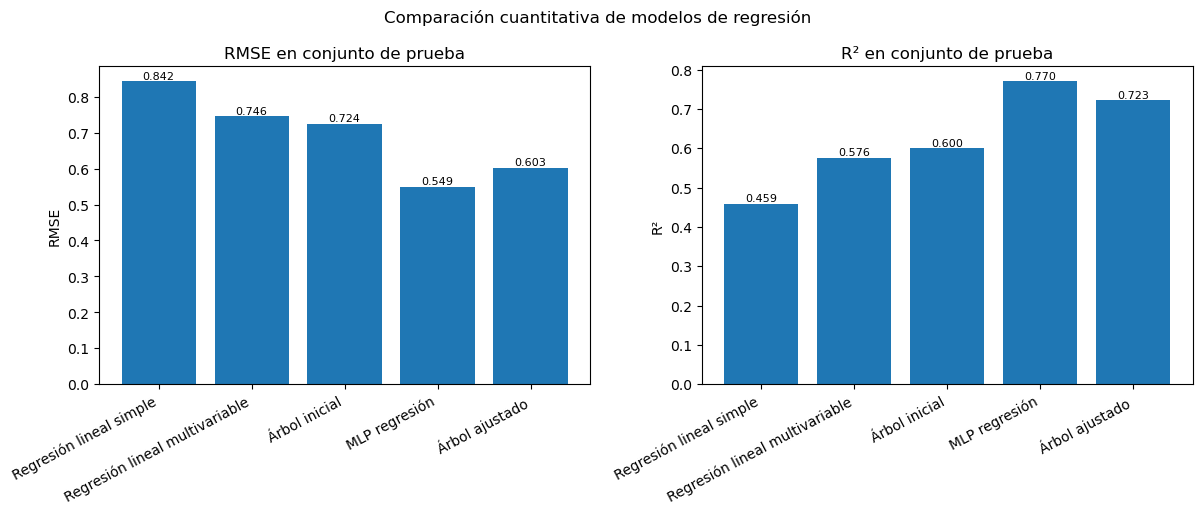

In [7]:
reg_rows = []
for name in reg_models:
    yhat_train = reg_pred_train[name]
    yhat_test = reg_pred_test[name]
    mse_train = mean_squared_error(y_train_reg, yhat_train)
    mse_test = mean_squared_error(y_test_reg, yhat_test)
    reg_rows.append({
        'Modelo': name,
        'MSE_train': mse_train,
        'RMSE_train': np.sqrt(mse_train),
        'R2_train': r2_score(y_train_reg, yhat_train),
        'MSE_test': mse_test,
        'RMSE_test': np.sqrt(mse_test),
        'R2_test': r2_score(y_test_reg, yhat_test),
    })
reg_metrics = pd.DataFrame(reg_rows)
reg_metrics['Gap_R2_train_test'] = reg_metrics['R2_train'] - reg_metrics['R2_test']
reg_metrics['Gap_RMSE_test_train'] = reg_metrics['RMSE_test'] - reg_metrics['RMSE_train']
reg_metrics.to_csv(OUT_DIR / '10_reg_metricas_comparacion.csv', index=False)
display(reg_metrics)

pred_reg = pd.DataFrame({'y_real': y_test_reg.reset_index(drop=True)})
for name, pred in reg_pred_test.items():
    pred_reg[name] = np.asarray(pred)
pred_reg.to_csv(OUT_DIR / '11_reg_predicciones_test.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))
labels = reg_metrics['Modelo']
x = np.arange(len(labels))
axes[0].bar(x, reg_metrics['RMSE_test'])
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=28, ha='right')
axes[0].set(title='RMSE en conjunto de prueba', ylabel='RMSE')
for i, value in enumerate(reg_metrics['RMSE_test']):
    axes[0].text(i, value, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

axes[1].bar(x, reg_metrics['R2_test'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=28, ha='right')
axes[1].set(title='R² en conjunto de prueba', ylabel='R²')
for i, value in enumerate(reg_metrics['R2_test']):
    axes[1].text(i, value, f'{value:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Comparación cuantitativa de modelos de regresión')
fig.tight_layout()
fig.savefig(FIG_DIR / '04_reg_comparacion_metricas.png', dpi=180, bbox_inches='tight')
plt.show()


# 2. Fase 3 · Clasificación supervisada mediante redes neuronales
## 2.1 Conjunto de datos, variable objetivo y predictores

Se utiliza Titanic con `survived` como variable objetivo binaria. Los predictores considerados son `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `embarked`. Las variables redundantes, derivadas o asociadas a fuga de información se excluyen del modelamiento.


In [8]:
CLF_DATA = DATA_DIR / 'titanic.csv'
clf_df = pd.read_csv(CLF_DATA)
TARGET_CLF = 'survived'
NUM_FEATURES_CLF = ['pclass', 'age', 'sibsp', 'parch', 'fare']
CAT_FEATURES_CLF = ['sex', 'embarked']
FEATURES_CLF = NUM_FEATURES_CLF + CAT_FEATURES_CLF

filas_repetidas_exactas = int(clf_df.duplicated().sum())

perfil_clf = pd.DataFrame({
    'Elemento': [
        'Filas', 'Columnas_originales', 'Predictores_seleccionados',
        'Variable_objetivo', 'Filas_exactamente_repetidas'
    ],
    'Valor': [
        len(clf_df), clf_df.shape[1], len(FEATURES_CLF),
        TARGET_CLF, filas_repetidas_exactas
    ],
})

missing_clf = (
    clf_df[FEATURES_CLF + [TARGET_CLF]].isna().sum()
    .rename('Valores_faltantes').reset_index().rename(columns={'index':'Variable'})
)

selection_clf = pd.DataFrame([
    {'Variable':'survived',    'Rol_decision':'Objetivo binario'},
    {'Variable':'pclass',      'Rol_decision':'Predictora ordinal (tratada numéricamente)'},
    {'Variable':'age',         'Rol_decision':'Predictora numérica continua'},
    {'Variable':'sibsp',       'Rol_decision':'Predictora numérica discreta'},
    {'Variable':'parch',       'Rol_decision':'Predictora numérica discreta'},
    {'Variable':'fare',        'Rol_decision':'Predictora numérica continua'},
    {'Variable':'sex',         'Rol_decision':'Predictora categórica binaria'},
    {'Variable':'embarked',    'Rol_decision':'Predictora categórica nominal'},
    {'Variable':'class',       'Rol_decision':'Excluida: redundante con pclass'},
    {'Variable':'who',         'Rol_decision':'Excluida: derivada de sex/age'},
    {'Variable':'adult_male',  'Rol_decision':'Excluida: derivada de sex/age'},
    {'Variable':'deck',        'Rol_decision':'Excluida: alta ausencia'},
    {'Variable':'embark_town', 'Rol_decision':'Excluida: redundante con embarked'},
    {'Variable':'alive',       'Rol_decision':'Excluida: fuga de información respecto de survived'},
    {'Variable':'alone',       'Rol_decision':'Excluida: derivada de sibsp/parch'},
])

control_repetidos_clf = pd.DataFrame([{
    'Hallazgo':'Filas exactamente repetidas considerando las 15 columnas',
    'Cantidad':filas_repetidas_exactas,
    'Decision':'Conservar',
    'Justificacion':(
        'El dataset no contiene un identificador único de pasajero; una coincidencia exacta '
        'de atributos no permite demostrar que se trate de un registro duplicado. '
        'Se conserva la muestra canónica de 891 observaciones.'
    )
}])

perfil_clf.to_csv(OUT_DIR / '12_clf_perfil_dataset.csv', index=False)
missing_clf.to_csv(OUT_DIR / '13_clf_valores_faltantes.csv', index=False)
selection_clf.to_csv(OUT_DIR / '14_clf_seleccion_variables.csv', index=False)
control_repetidos_clf.to_csv(OUT_DIR / '14b_clf_control_filas_repetidas.csv', index=False)

display(perfil_clf)
display(missing_clf)
display(selection_clf)
display(control_repetidos_clf)


,Elemento,Valor
0,Filas,891
1,Columnas_originales,15
2,Predictores_seleccionados,7
3,Variable_objetivo,survived
4,Filas_exactamente_repetidas,107


,Variable,Valores_faltantes
0,pclass,0
1,age,177
2,sibsp,0
3,parch,0
4,fare,0
5,sex,0
6,embarked,2
7,survived,0


,Variable,Rol_decision
0,survived,Objetivo binario
1,pclass,Predictora ordinal (tratada numéricamente)
2,age,Predictora numérica continua
3,sibsp,Predictora numérica discreta
4,parch,Predictora numérica discreta
5,fare,Predictora numérica continua
6,sex,Predictora categórica binaria
7,embarked,Predictora categórica nominal
8,class,Excluida: redundante con pclass
9,who,Excluida: derivada de sex/age


,Hallazgo,Cantidad,Decision,Justificacion
0,Filas exactamente repetidas considerando las 1...,107,Conservar,El dataset no contiene un identificador único ...


## 2.2 Análisis exploratorio inicial

Se documentan la distribución de clases, los valores faltantes y el comportamiento de variables relevantes antes del entrenamiento. Se calculan tasas de la clase positiva por variables categóricas y estadísticos descriptivos de variables numéricas condicionados por la clase.


,Clase,Frecuencia,Porcentaje
0,0,549,61.616162
1,1,342,38.383838


,Metrica,Valor
0,Proporcion_mayoritaria,0.616162
1,Proporcion_minoritaria,0.383838
2,Razon_mayoritaria_minoritaria,1.605263


,Variable,Categoria,N,Tasa_clase_1
0,sex,female,314,0.742038
1,sex,male,577,0.188908
2,pclass,1,216,0.629630
3,pclass,2,184,0.472826
4,pclass,3,491,0.242363
5,embarked,C,168,0.553571
6,embarked,Q,77,0.389610
7,embarked,S,644,0.336957
8,embarked,NaN,2,1.000000


,survived,age_count,age_mean,age_median,age_std,fare_count,fare_mean,fare_median,fare_std,sibsp_count,sibsp_mean,sibsp_median,sibsp_std,parch_count,parch_mean,parch_median,parch_std
0,0,424,30.626179,28.0,14.172110,549,22.117887,10.5,31.388207,549,0.553734,0.0,1.288399,549,0.329690,0.0,0.823166
1,1,290,28.343690,28.0,14.950952,342,48.395408,26.0,66.596998,342,0.473684,0.0,0.708688,342,0.464912,0.0,0.771712


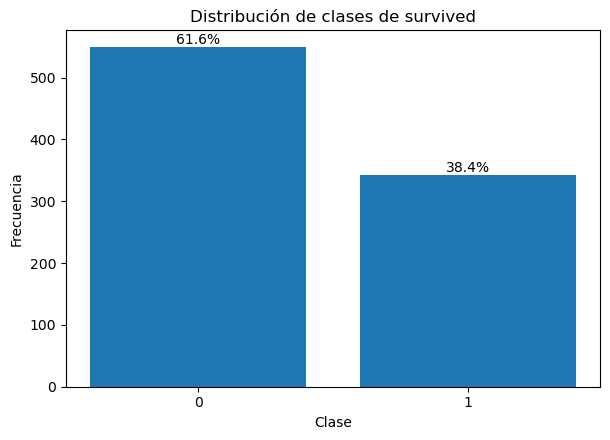

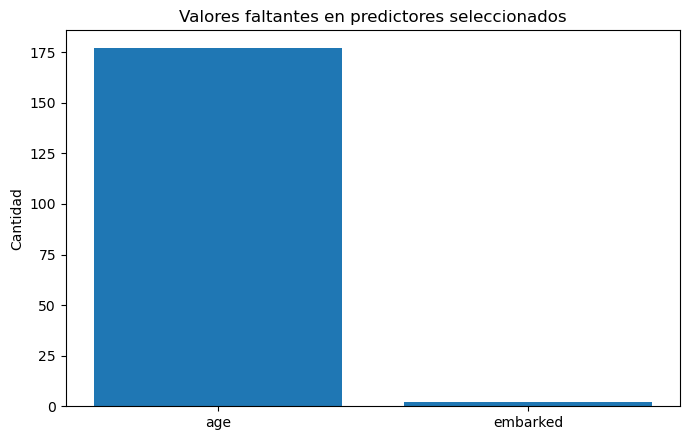

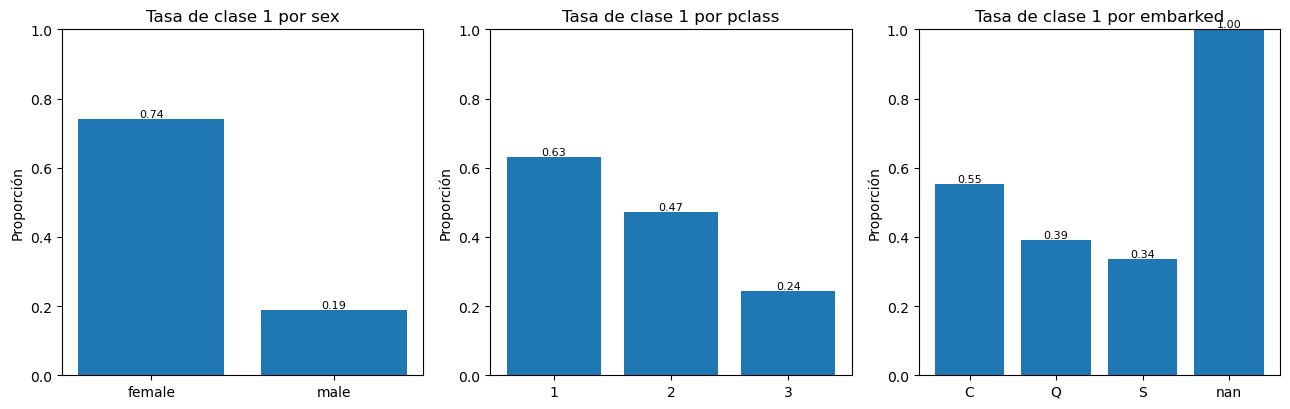

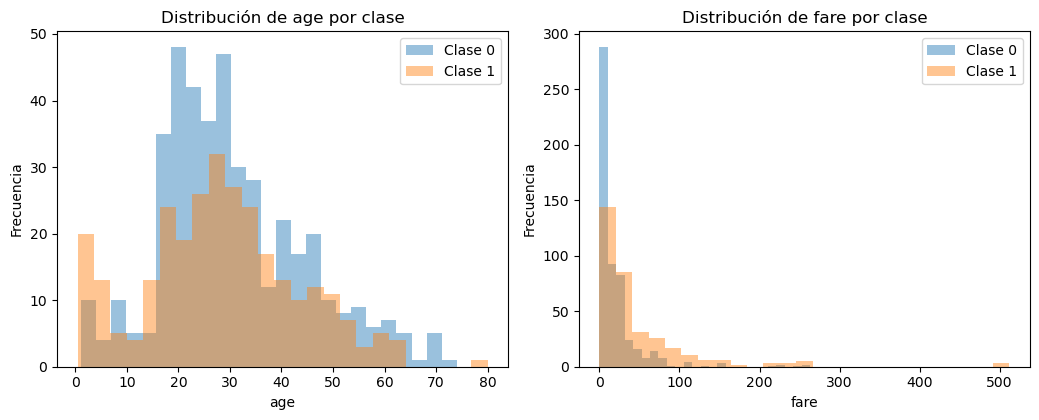

In [9]:
class_dist = (
    clf_df[TARGET_CLF].value_counts().sort_index().rename_axis('Clase')
    .reset_index(name='Frecuencia')
)
class_dist['Porcentaje'] = 100 * class_dist['Frecuencia'] / class_dist['Frecuencia'].sum()
class_dist.to_csv(OUT_DIR / '15_clf_distribucion_clases.csv', index=False)

balance_clf = pd.DataFrame({
    'Metrica': ['Proporcion_mayoritaria', 'Proporcion_minoritaria', 'Razon_mayoritaria_minoritaria'],
    'Valor': [
        class_dist['Frecuencia'].max()/class_dist['Frecuencia'].sum(),
        class_dist['Frecuencia'].min()/class_dist['Frecuencia'].sum(),
        class_dist['Frecuencia'].max()/class_dist['Frecuencia'].min(),
    ]
})
balance_clf.to_csv(OUT_DIR / '16_clf_diagnostico_balance.csv', index=False)

patrones = []
for var in ['sex', 'pclass', 'embarked']:
    tabla = clf_df.groupby(var, dropna=False)[TARGET_CLF].agg(['count','mean']).reset_index()
    tabla['Variable'] = var
    tabla = tabla.rename(columns={var:'Categoria', 'count':'N', 'mean':'Tasa_clase_1'})
    patrones.append(tabla[['Variable','Categoria','N','Tasa_clase_1']])
patrones_clf = pd.concat(patrones, ignore_index=True)
patrones_clf.to_csv(OUT_DIR / '17_clf_patrones_categoricos.csv', index=False)

numeric_patterns = (
    clf_df.groupby(TARGET_CLF)[['age','fare','sibsp','parch']]
    .agg(['count','mean','median','std'])
)
numeric_patterns.columns = ['_'.join(c) for c in numeric_patterns.columns]
numeric_patterns = numeric_patterns.reset_index()
numeric_patterns.to_csv(OUT_DIR / '18_clf_patrones_numericos.csv', index=False)

display(class_dist)
display(balance_clf)
display(patrones_clf)
display(numeric_patterns)

fig, ax = plt.subplots(figsize=(6.2,4.5))
ax.bar(class_dist['Clase'].astype(str), class_dist['Frecuencia'])
for i,row in class_dist.iterrows():
    ax.text(i, row['Frecuencia'], f"{row['Porcentaje']:.1f}%", ha='center', va='bottom')
ax.set(title='Distribución de clases de survived', xlabel='Clase', ylabel='Frecuencia')
fig.tight_layout()
fig.savefig(FIG_DIR / '05_clf_distribucion_clases.png', dpi=180, bbox_inches='tight')
plt.show()

miss_plot = missing_clf[missing_clf['Valores_faltantes'] > 0]
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(miss_plot['Variable'], miss_plot['Valores_faltantes'])
ax.set(title='Valores faltantes en predictores seleccionados', ylabel='Cantidad')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_clf_valores_faltantes.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1,3,figsize=(13,4.2))
for ax,var in zip(axes,['sex','pclass','embarked']):
    tab = patrones_clf[patrones_clf['Variable']==var]
    bars = ax.bar(tab['Categoria'].astype(str), tab['Tasa_clase_1'])
    ax.set(title=f'Tasa de clase 1 por {var}', ylabel='Proporción', ylim=(0, 1))
    for bar, value in zip(bars, tab['Tasa_clase_1']):
        ax.text(bar.get_x() + bar.get_width()/2, value, f'{value:.2f}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / '07_clf_patrones_categoricos.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1,2,figsize=(10.5,4.3))
for cls, grp in clf_df.groupby(TARGET_CLF):
    axes[0].hist(grp['age'].dropna(), bins=25, alpha=0.45, label=f'Clase {cls}')
    axes[1].hist(grp['fare'].dropna(), bins=25, alpha=0.45, label=f'Clase {cls}')
axes[0].set(title='Distribución de age por clase', xlabel='age', ylabel='Frecuencia')
axes[1].set(title='Distribución de fare por clase', xlabel='fare', ylabel='Frecuencia')
for ax in axes: ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '08_clf_patrones_numericos.png', dpi=180, bbox_inches='tight')
plt.show()


## 2.3 Partición y preprocesamiento

La partición entrenamiento/prueba se realiza antes de aprender imputaciones, codificación o escalamiento. Se utiliza estratificación para conservar la proporción de clases. El preprocesamiento se ajusta exclusivamente con entrenamiento mediante `ColumnTransformer` y luego se aplica al conjunto de prueba.


In [10]:
X_clf = clf_df[FEATURES_CLF].copy()
y_clf = clf_df[TARGET_CLF].copy()

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf
)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])
preprocessor_clf = ColumnTransformer([
    ('num', num_pipe, NUM_FEATURES_CLF),
    ('cat', cat_pipe, CAT_FEATURES_CLF),
], remainder='drop', verbose_feature_names_out=False)

X_train_clf_proc = preprocessor_clf.fit_transform(X_train_clf)
X_test_clf_proc = preprocessor_clf.transform(X_test_clf)
feature_names_clf = preprocessor_clf.get_feature_names_out()

split_clf = pd.DataFrame({
    'Objeto':['X_train','X_test','y_train','y_test'],
    'Filas':[len(X_train_clf),len(X_test_clf),len(y_train_clf),len(y_test_clf)],
})
split_clf.to_csv(OUT_DIR / '19_clf_dimensiones_split.csv', index=False)
pd.DataFrame({'Variable_transformada':feature_names_clf}).to_csv(
    OUT_DIR / '20_clf_variables_transformadas.csv', index=False
)

partition_balance = pd.concat([
    y_train_clf.value_counts(normalize=True).sort_index().rename('train'),
    y_test_clf.value_counts(normalize=True).sort_index().rename('test'),
], axis=1).reset_index().rename(columns={'index':'Clase'})
partition_balance.to_csv(OUT_DIR / '21_clf_balance_train_test.csv', index=False)

control_preproc_clf = pd.DataFrame({
    'Control': ['Predictores_transformados', 'NaN_train_transformado', 'NaN_test_transformado'],
    'Valor': [
        int(X_train_clf_proc.shape[1]),
        int(np.isnan(X_train_clf_proc).sum()),
        int(np.isnan(X_test_clf_proc).sum()),
    ],
})
control_preproc_clf.to_csv(OUT_DIR / '21b_clf_control_preprocesamiento.csv', index=False)

display(split_clf)
display(pd.DataFrame({'Variable_transformada':feature_names_clf}))
display(partition_balance)
display(control_preproc_clf)


,Objeto,Filas
0,X_train,712
1,X_test,179
2,y_train,712
3,y_test,179


,Variable_transformada
0,pclass
1,age
2,sibsp
3,parch
4,fare
5,sex_male
6,embarked_Q
7,embarked_S


,survived,train,test
0,0,0.616573,0.614525
1,1,0.383427,0.385475


,Control,Valor
0,Predictores_transformados,8
1,NaN_train_transformado,0
2,NaN_test_transformado,0


## 2.4 Arquitecturas y configuración experimental

Se comparan tres arquitecturas MLP: `(100,)`, `(100, 50)` y `(100, 50, 25)`. Los demás hiperparámetros se mantienen constantes para que la comparación se concentre en la profundidad y distribución de neuronas ocultas. Se utiliza la misma estrategia de validación interna y `early_stopping` en las tres arquitecturas.


In [11]:
architectures = {
    'MLP 1 capa oculta': (100,),
    'MLP 2 capas ocultas': (100, 50),
    'MLP 3 capas ocultas': (100, 50, 25),
}
common_params = {
    'activation':'relu',
    'solver':'adam',
    'alpha':0.0001,
    'batch_size':'auto',
    'learning_rate':'constant',
    'learning_rate_init':0.001,
    'max_iter':500,
    'early_stopping':True,
    'validation_fraction':0.15,
    'n_iter_no_change':20,
    'tol':1e-4,
    'random_state':RANDOM_STATE,
}

fichas_mlp = pd.DataFrame([
    {'Modelo':name, 'hidden_layer_sizes':str(arch), **common_params}
    for name,arch in architectures.items()
])
fichas_mlp.to_csv(OUT_DIR / '22_clf_fichas_tecnicas_mlp.csv', index=False)
display(fichas_mlp)


,Modelo,hidden_layer_sizes,activation,solver,alpha,batch_size,learning_rate,learning_rate_init,max_iter,early_stopping,validation_fraction,n_iter_no_change,tol,random_state
0,MLP 1 capa oculta,"(100,)",relu,adam,0.0001,auto,constant,0.001,500,True,0.15,20,0.0001,42
1,MLP 2 capas ocultas,"(100, 50)",relu,adam,0.0001,auto,constant,0.001,500,True,0.15,20,0.0001,42
2,MLP 3 capas ocultas,"(100, 50, 25)",relu,adam,0.0001,auto,constant,0.001,500,True,0.15,20,0.0001,42


## 2.5 Entrenamiento y evaluación de las arquitecturas

Cada arquitectura se ajusta sobre la misma matriz de entrenamiento procesada y se evalúa sobre el mismo conjunto de prueba. Se registran matriz de confusión, accuracy, precision, recall, F1-score, balanced accuracy, especificidad, iteraciones, pérdida, complejidad paramétrica, tiempo de ajuste y métricas train/test.


In [12]:
clf_models = {}
clf_matrices = {}
metric_rows = []
gen_rows = []
warning_rows = []
loss_rows = []
validation_rows = []
pred_test_table = pd.DataFrame({'y_real': y_test_clf.reset_index(drop=True)})

for name, arch in architectures.items():
    model = MLPClassifier(hidden_layer_sizes=arch, **common_params)
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        model.fit(X_train_clf_proc, y_train_clf)
    fit_seconds = time.perf_counter() - start

    pred_train = model.predict(X_train_clf_proc)
    pred_test = model.predict(X_test_clf_proc)
    cm = confusion_matrix(y_test_clf, pred_test, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    params_count = int(sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_))

    clf_models[name] = model
    clf_matrices[name] = cm
    pred_test_table[name] = pred_test

    metric_rows.append({
        'Modelo':name,
        'Accuracy':accuracy_score(y_test_clf, pred_test),
        'Precision':precision_score(y_test_clf, pred_test, zero_division=0),
        'Recall':recall_score(y_test_clf, pred_test, zero_division=0),
        'F1_score':f1_score(y_test_clf, pred_test, zero_division=0),
        'Balanced_accuracy':balanced_accuracy_score(y_test_clf, pred_test),
        'Especificidad':tn/(tn+fp) if (tn+fp) else np.nan,
        'TN':int(tn), 'FP':int(fp), 'FN':int(fn), 'TP':int(tp),
        'Iteraciones':int(model.n_iter_),
        'Detencion_antes_max_iter':bool(model.n_iter_ < common_params['max_iter']),
        'Best_validation_score':float(getattr(model, 'best_validation_score_', np.nan)),
        'Loss_final':float(model.loss_),
        'Parametros_entrenables':params_count,
        'Tiempo_ajuste_segundos':fit_seconds,
    })
    gen_rows.append({
        'Modelo':name,
        'Accuracy_train':accuracy_score(y_train_clf, pred_train),
        'Accuracy_test':accuracy_score(y_test_clf, pred_test),
        'Gap_accuracy_train_test':accuracy_score(y_train_clf, pred_train)-accuracy_score(y_test_clf, pred_test),
        'F1_train':f1_score(y_train_clf, pred_train, zero_division=0),
        'F1_test':f1_score(y_test_clf, pred_test, zero_division=0),
        'Gap_F1_train_test':f1_score(y_train_clf, pred_train, zero_division=0)-f1_score(y_test_clf, pred_test, zero_division=0),
    })
    for w in caught:
        warning_rows.append({'Modelo':name, 'Categoria':w.category.__name__, 'Mensaje':str(w.message)})
    for i, loss in enumerate(model.loss_curve_, start=1):
        loss_rows.append({'Modelo':name, 'Iteracion':i, 'Loss':float(loss)})
    if getattr(model, 'validation_scores_', None) is not None:
        for i, score in enumerate(model.validation_scores_, start=1):
            validation_rows.append({'Modelo':name, 'Iteracion':i, 'Validation_score':float(score)})

metricas_mlp = pd.DataFrame(metric_rows)
generalizacion_mlp = pd.DataFrame(gen_rows)
advertencias_mlp = pd.DataFrame(warning_rows, columns=['Modelo','Categoria','Mensaje'])
curvas_loss = pd.DataFrame(loss_rows)
curvas_validation = pd.DataFrame(validation_rows)

metricas_mlp.to_csv(OUT_DIR / '23_clf_metricas_mlp.csv', index=False)
generalizacion_mlp.to_csv(OUT_DIR / '24_clf_generalizacion_mlp.csv', index=False)
advertencias_mlp.to_csv(OUT_DIR / '25_clf_advertencias_mlp.csv', index=False)
curvas_loss.to_csv(OUT_DIR / '26_clf_curvas_loss.csv', index=False)
curvas_validation.to_csv(OUT_DIR / '27_clf_curvas_validacion.csv', index=False)
pred_test_table.to_csv(OUT_DIR / '28_clf_predicciones_test.csv', index=False)

display(metricas_mlp)
display(generalizacion_mlp)
if len(advertencias_mlp):
    display(advertencias_mlp)
else:
    print('Advertencias de entrenamiento registradas: 0')


,Modelo,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,TN,FP,FN,TP,Iteraciones,Detencion_antes_max_iter,Best_validation_score,Loss_final,Parametros_entrenables,Tiempo_ajuste_segundos
0,MLP 1 capa oculta,0.776536,0.754386,0.623188,0.682540,0.747958,0.872727,96,14,26,43,72,True,0.785047,0.423612,1001,0.560787
1,MLP 2 capas ocultas,0.793296,0.735294,0.724638,0.729927,0.780501,0.836364,92,18,19,50,52,True,0.878505,0.404834,6001,0.524082
2,MLP 3 capas ocultas,0.787709,0.816327,0.579710,0.677966,0.748946,0.918182,101,9,29,40,50,True,0.813084,0.379368,7251,0.587541


,Modelo,Accuracy_train,Accuracy_test,Gap_accuracy_train_test,F1_train,F1_test,Gap_F1_train_test
0,MLP 1 capa oculta,0.806180,0.776536,0.029643,0.726190,0.682540,0.043651
1,MLP 2 capas ocultas,0.824438,0.793296,0.031142,0.772313,0.729927,0.042386
2,MLP 3 capas ocultas,0.838483,0.787709,0.050774,0.760915,0.677966,0.082949


Advertencias de entrenamiento registradas: 0


## 2.6 Matrices de confusión y curvas de entrenamiento

Las matrices y curvas se generan directamente desde los modelos ajustados en la corrida actual y se guardan como evidencia reproducible.


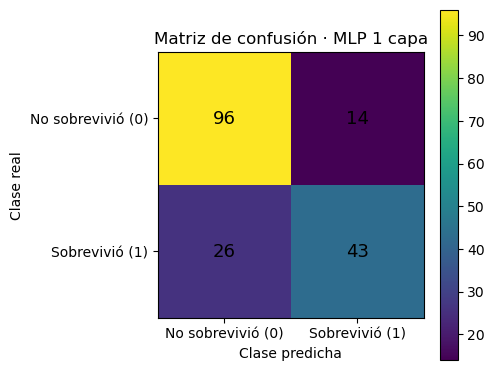

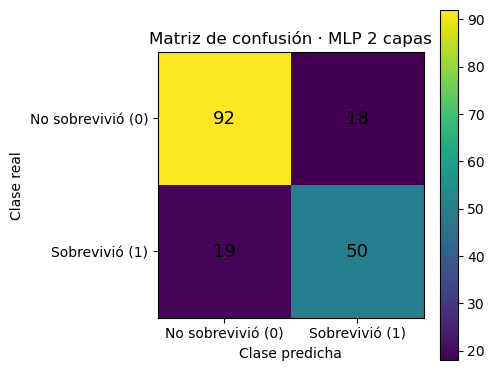

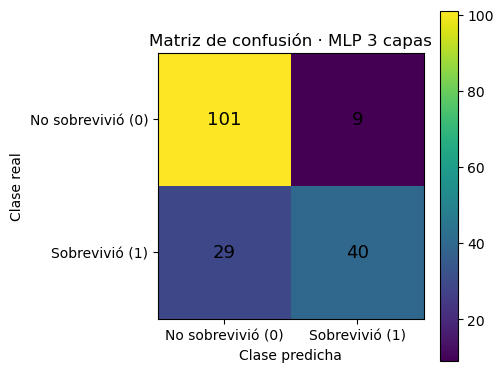

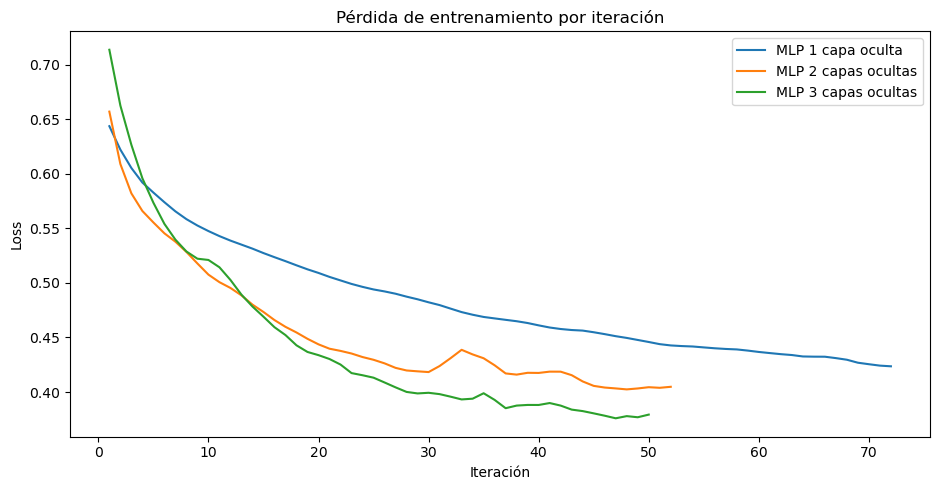

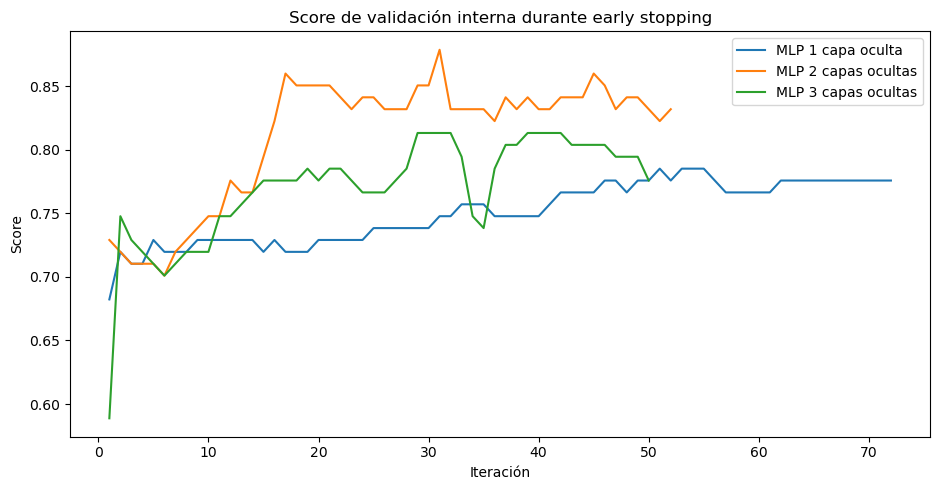

In [13]:
for idx, (name, cm) in enumerate(clf_matrices.items(), start=1):
    cm_df = pd.DataFrame(cm, index=['Real_0_no_sobrevivio','Real_1_sobrevivio'], columns=['Pred_0_no_sobrevivio','Pred_1_sobrevivio'])
    cm_df.to_csv(OUT_DIR / f'29_{idx}_matriz_confusion.csv')
    fig, ax = plt.subplots(figsize=(5.1,4.3))
    im = ax.imshow(cm)
    for (i,j), value in np.ndenumerate(cm):
        ax.text(j, i, str(value), ha='center', va='center', fontsize=13)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['No sobrevivió (0)','Sobrevivió (1)']); ax.set_yticklabels(['No sobrevivió (0)','Sobrevivió (1)'])
    titulo_cm = {1:'MLP 1 capa', 2:'MLP 2 capas', 3:'MLP 3 capas'}[idx]
    ax.set(title=f'Matriz de confusión · {titulo_cm}', xlabel='Clase predicha', ylabel='Clase real')
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'09_{idx}_matriz_confusion.png', dpi=180, bbox_inches='tight')
    plt.show()

fig, ax = plt.subplots(figsize=(9.5,5.0))
for name, model in clf_models.items():
    ax.plot(np.arange(1,len(model.loss_curve_)+1), model.loss_curve_, label=name)
ax.set(title='Pérdida de entrenamiento por iteración', xlabel='Iteración', ylabel='Loss')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '12_clf_curvas_loss.png', dpi=180, bbox_inches='tight')
plt.show()

if len(curvas_validation):
    fig, ax = plt.subplots(figsize=(9.5,5.0))
    for name in architectures:
        sub = curvas_validation[curvas_validation['Modelo']==name]
        if len(sub):
            ax.plot(sub['Iteracion'], sub['Validation_score'], label=name)
    ax.set(title='Score de validación interna durante early stopping', xlabel='Iteración', ylabel='Score')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / '13_clf_curvas_validacion.png', dpi=180, bbox_inches='tight')
    plt.show()


## 2.7 Comparación tabulada de arquitecturas

La tabla comparativa reúne métricas de desempeño, tipos de error, complejidad y brecha train–test de las tres arquitecturas. La selección del modelo se realizará en el informe después de verificar la corrida ejecutada.


,Modelo,Accuracy,Precision,Recall,F1_score,Balanced_accuracy,Especificidad,TN,FP,FN,...,Best_validation_score,Loss_final,Parametros_entrenables,Tiempo_ajuste_segundos,Accuracy_train,Accuracy_test,Gap_accuracy_train_test,F1_train,F1_test,Gap_F1_train_test
0,MLP 1 capa oculta,0.776536,0.754386,0.623188,0.682540,0.747958,0.872727,96,14,26,...,0.785047,0.423612,1001,0.560787,0.806180,0.776536,0.029643,0.726190,0.682540,0.043651
1,MLP 2 capas ocultas,0.793296,0.735294,0.724638,0.729927,0.780501,0.836364,92,18,19,...,0.878505,0.404834,6001,0.524082,0.824438,0.793296,0.031142,0.772313,0.729927,0.042386
2,MLP 3 capas ocultas,0.787709,0.816327,0.579710,0.677966,0.748946,0.918182,101,9,29,...,0.813084,0.379368,7251,0.587541,0.838483,0.787709,0.050774,0.760915,0.677966,0.082949


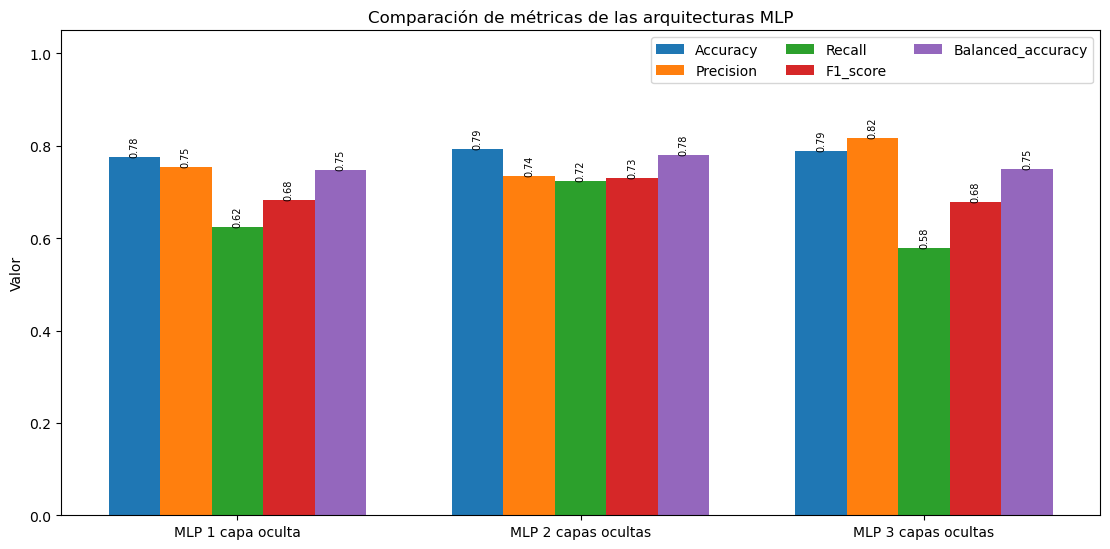

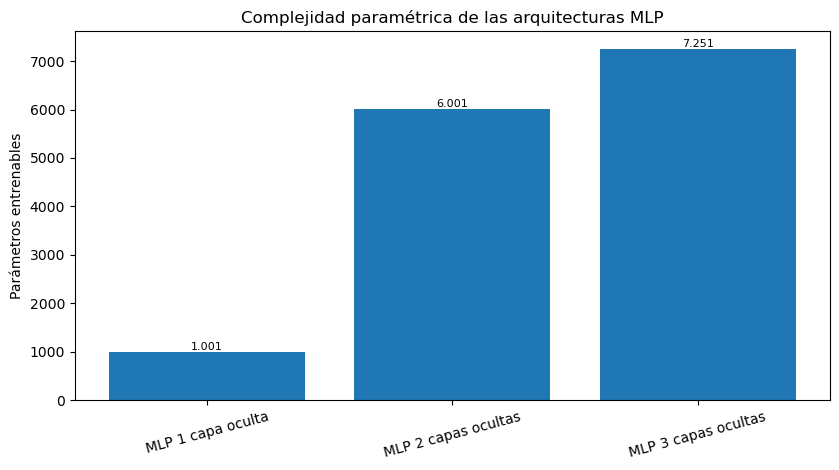

In [14]:
comparacion_mlp = metricas_mlp.merge(generalizacion_mlp, on='Modelo', how='left')
comparacion_mlp.to_csv(OUT_DIR / '32_clf_comparacion_arquitecturas.csv', index=False)
display(comparacion_mlp)

metric_cols = ['Accuracy','Precision','Recall','F1_score','Balanced_accuracy']
fig, ax = plt.subplots(figsize=(11.2,5.6))
x = np.arange(len(metricas_mlp))
w = 0.15
for k,col in enumerate(metric_cols):
    positions = x + (k-2)*w
    bars = ax.bar(positions, metricas_mlp[col], width=w, label=col)
    for bar, value in zip(bars, metricas_mlp[col]):
        ax.text(bar.get_x()+bar.get_width()/2, value, f'{value:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_xticks(x)
ax.set_xticklabels(metricas_mlp['Modelo'])
ax.set_ylim(0,1.05)
ax.set(title='Comparación de métricas de las arquitecturas MLP', ylabel='Valor')
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / '14_clf_comparacion_metricas_mlp.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8.5,4.8))
bars = ax.bar(metricas_mlp['Modelo'], metricas_mlp['Parametros_entrenables'])
ax.set(title='Complejidad paramétrica de las arquitecturas MLP', ylabel='Parámetros entrenables')
ax.tick_params(axis='x', rotation=15)
for bar, value in zip(bars, metricas_mlp['Parametros_entrenables']):
    ax.text(bar.get_x()+bar.get_width()/2, value, f'{int(value):,}'.replace(',', '.'), ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / '15_clf_complejidad_parametrica.png', dpi=180, bbox_inches='tight')
plt.show()


# 3. Control de la corrida

La celda final verifica la existencia de las tablas y figuras necesarias, registra un manifiesto con huellas SHA-256 y genera metadatos básicos de la ejecución.


In [15]:
required_outputs = [
    '01_reg_perfil_dataset.csv',
    '04_reg_dimensiones_split.csv',
    '07_reg_fichas_configuracion_inicial.csv',
    '08_reg_ajuste_hiperparametros_cv.csv',
    '09_reg_mejores_hiperparametros.json',
    '10_reg_metricas_comparacion.csv',
    '12_clf_perfil_dataset.csv',
    '14b_clf_control_filas_repetidas.csv',
    '15_clf_distribucion_clases.csv',
    '17_clf_patrones_categoricos.csv',
    '18_clf_patrones_numericos.csv',
    '19_clf_dimensiones_split.csv',
    '21b_clf_control_preprocesamiento.csv',
    '22_clf_fichas_tecnicas_mlp.csv',
    '23_clf_metricas_mlp.csv',
    '24_clf_generalizacion_mlp.csv',
    '32_clf_comparacion_arquitecturas.csv',
]
required_figures = [
    '01_reg_distribucion_medhouseval.png',
    '03_reg_ajuste_hiperparametros_cv.png',
    '04_reg_comparacion_metricas.png',
    '05_clf_distribucion_clases.png',
    '06_clf_valores_faltantes.png',
    '07_clf_patrones_categoricos.png',
    '08_clf_patrones_numericos.png',
    '09_1_matriz_confusion.png',
    '09_2_matriz_confusion.png',
    '09_3_matriz_confusion.png',
    '12_clf_curvas_loss.png',
    '13_clf_curvas_validacion.png',
    '14_clf_comparacion_metricas_mlp.png',
    '15_clf_complejidad_parametrica.png',
]

checks=[]
for name in required_outputs:
    p=OUT_DIR/name
    checks.append({'Tipo':'output','Archivo':name,'Existe':p.exists(),'Bytes':p.stat().st_size if p.exists() else 0})
for name in required_figures:
    p=FIG_DIR/name
    checks.append({'Tipo':'figure','Archivo':name,'Existe':p.exists(),'Bytes':p.stat().st_size if p.exists() else 0})
check_df=pd.DataFrame(checks)
check_df.to_csv(OUT_DIR/'33_control_artefactos_requeridos.csv',index=False)
display(check_df)

missing = check_df.loc[~check_df['Existe'], 'Archivo'].tolist()
if missing:
    raise RuntimeError('Faltan artefactos requeridos: ' + ', '.join(missing))

artefactos=[]
for folder in (OUT_DIR,FIG_DIR):
    for p in sorted(folder.iterdir()):
        if p.is_file() and p.name not in {'.gitkeep','README.md'}:
            h=hashlib.sha256(p.read_bytes()).hexdigest()
            artefactos.append({
                'Ruta':p.relative_to(ROOT).as_posix(),
                'Bytes':p.stat().st_size,
                'SHA256':h,
            })
manifest_df=pd.DataFrame(artefactos)
manifest_df.to_csv(OUT_DIR/'34_manifiesto_artefactos.csv',index=False)

run_metadata={
    'random_state':RANDOM_STATE,
    'filas_california_housing':int(len(reg_df)),
    'filas_titanic':int(len(clf_df)),
    'arquitecturas_mlp':{k:list(v) for k,v in architectures.items()},
    'artefactos_generados':int(len(artefactos)),
}
with open(OUT_DIR/'35_metadata_ejecucion.json','w',encoding='utf-8') as f:
    json.dump(run_metadata,f,ensure_ascii=False,indent=2)

print('Validación de artefactos: OK')
print('Artefactos generados:', len(artefactos))
print('Guarde el notebook después de ejecutar todas las celdas antes de comprimir el repositorio.')


,Tipo,Archivo,Existe,Bytes
0,output,01_reg_perfil_dataset.csv,True,109
1,output,04_reg_dimensiones_split.csv,True,99
2,output,07_reg_fichas_configuracion_inicial.csv,True,475
3,output,08_reg_ajuste_hiperparametros_cv.csv,True,8023
4,output,09_reg_mejores_hiperparametros.json,True,77
5,output,10_reg_metricas_comparacion.csv,True,990
6,output,12_clf_perfil_dataset.csv,True,141
7,output,14b_clf_control_filas_repetidas.csv,True,326
8,output,15_clf_distribucion_clases.csv,True,79
9,output,17_clf_patrones_categoricos.csv,True,328


Validación de artefactos: OK
Artefactos generados: 51
Guarde el notebook después de ejecutar todas las celdas antes de comprimir el repositorio.
